# Random Forest Classifier on Baseline Dataset
We use Random Forest to predict Sepsis from vital signal, lab test, and demographics data.

## Assistant Functions

In [2]:
def concat_patients(train_dir, patient_list):
    """
    Concatenate individual patient dataframes for
    the training, valid, or other dataframes.
    """
    p = pd.read_csv(train_dir + '/' + patient_list[0], sep="|")
    p['patient_id'] = patient_list[0][1:7]
    for i in range(1, len(patient_list)):
        p_n = pd.read_csv(train_dir + '/' + patient_list[i], sep="|")
        p_n['patient_id'] = patient_list[i][1:7]
        p = pd.concat([p, p_n])
    return p

def predictors_labels_allocator(df):
    """Allocate predictors and labels."""
    col_names = df.columns
    X = np.array(df[col_names[:-2]].values)
    y = df[col_names[-2]].values
    return X, y

def F(beta, precision, recall):
    """Calculate f-beta score."""
    return (beta*beta + 1)*precision*recall / (beta*beta*precision + recall)

## Load the data
Import standard modules.

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib

from sklearn import preprocessing
from sklearn.metrics import (precision_recall_curve, auc, roc_curve,
                             precision_score, recall_score, accuracy_score)
from sklearn.model_selection import GridSearchCV
from plot_metric.functions import BinaryClassification
from sklearn.ensemble import RandomForestClassifier

In [4]:
train_dir = './../Data/training_setA/baseline/train_baseline/'
valid_dir = './../Data/training_setA/baseline/val_baseline/'
test_dir  = './../Data/training_setA/baseline/test_baseline/'

TRAIN_PATH = train_dir + 'data_baseline_train.parquet'
VALID_PATH = valid_dir + 'data_baseline_valid.parquet'
TEST_PATH  = test_dir  + 'data_baseline_test.parquet'

tr_patients  = sorted(os.listdir(train_dir))
vld_patients = sorted(os.listdir(valid_dir))
ts_patients  = sorted(os.listdir(test_dir))

print('num training patients:', len(tr_patients))
print('num valid patients:',    len(vld_patients))
print('num test patients:',     len(ts_patients))

num training patients: 14237
num valid patients: 3051
num test patients: 3051


Concatenate patients into `train_df`, `valid_df`, and `test_df`.

In [5]:
try:
    if not all(os.path.exists(p) for p in [TRAIN_PATH, VALID_PATH, TEST_PATH]):
        raise FileNotFoundError("One or more parquet files missing")
    train_df = pd.read_parquet(TRAIN_PATH)
    valid_df = pd.read_parquet(VALID_PATH)
    test_df  = pd.read_parquet(TEST_PATH)
    print("Loaded data from parquet files")
except Exception as e:
    print(e)
    print("Creating new parquet files...")
    train_df = concat_patients(train_dir, tr_patients)
    valid_df = concat_patients(valid_dir, vld_patients)
    test_df  = concat_patients(test_dir,  ts_patients)
    train_df.to_parquet(TRAIN_PATH, index=False)
    valid_df.to_parquet(VALID_PATH, index=False)
    test_df.to_parquet(TEST_PATH,  index=False)
    print("Saved data to parquet files")

Loaded data from parquet files


Check missing data.

In [6]:
print('train data has missing values:', train_df.isnull().sum().sum() != 0)
print('valid data has missing values:', valid_df.isnull().sum().sum() != 0)
print('test data has missing values:', test_df.isnull().sum().sum() != 0)

train data has missing values: False
valid data has missing values: False
test data has missing values: False


## Random Forest Classification for Sepsis
Separate features (X) and labels (y), then fit the model on training data.

In [7]:
Xtr,  ytr  = predictors_labels_allocator(train_df)
Xvld, yvld = predictors_labels_allocator(valid_df)
Xts,  yts  = predictors_labels_allocator(test_df)

Define and fit a `StandardScaler` on training data.

In [8]:
scaler = preprocessing.StandardScaler()
scaler.fit(Xtr)
Xtr  = scaler.transform(Xtr)
Xvld = scaler.transform(Xvld)
Xts  = scaler.transform(Xts)

Create a `Random Forest` model and fit on training data.

In [9]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(Xtr, ytr)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Measure validation accuracy.

In [10]:
yhat = model.predict(Xvld)
acc = np.mean(yhat == yvld)
print('Accuracy on the validation data is {0:f}'.format(acc))

Accuracy on the validation data is 0.978125


## Feature Importance

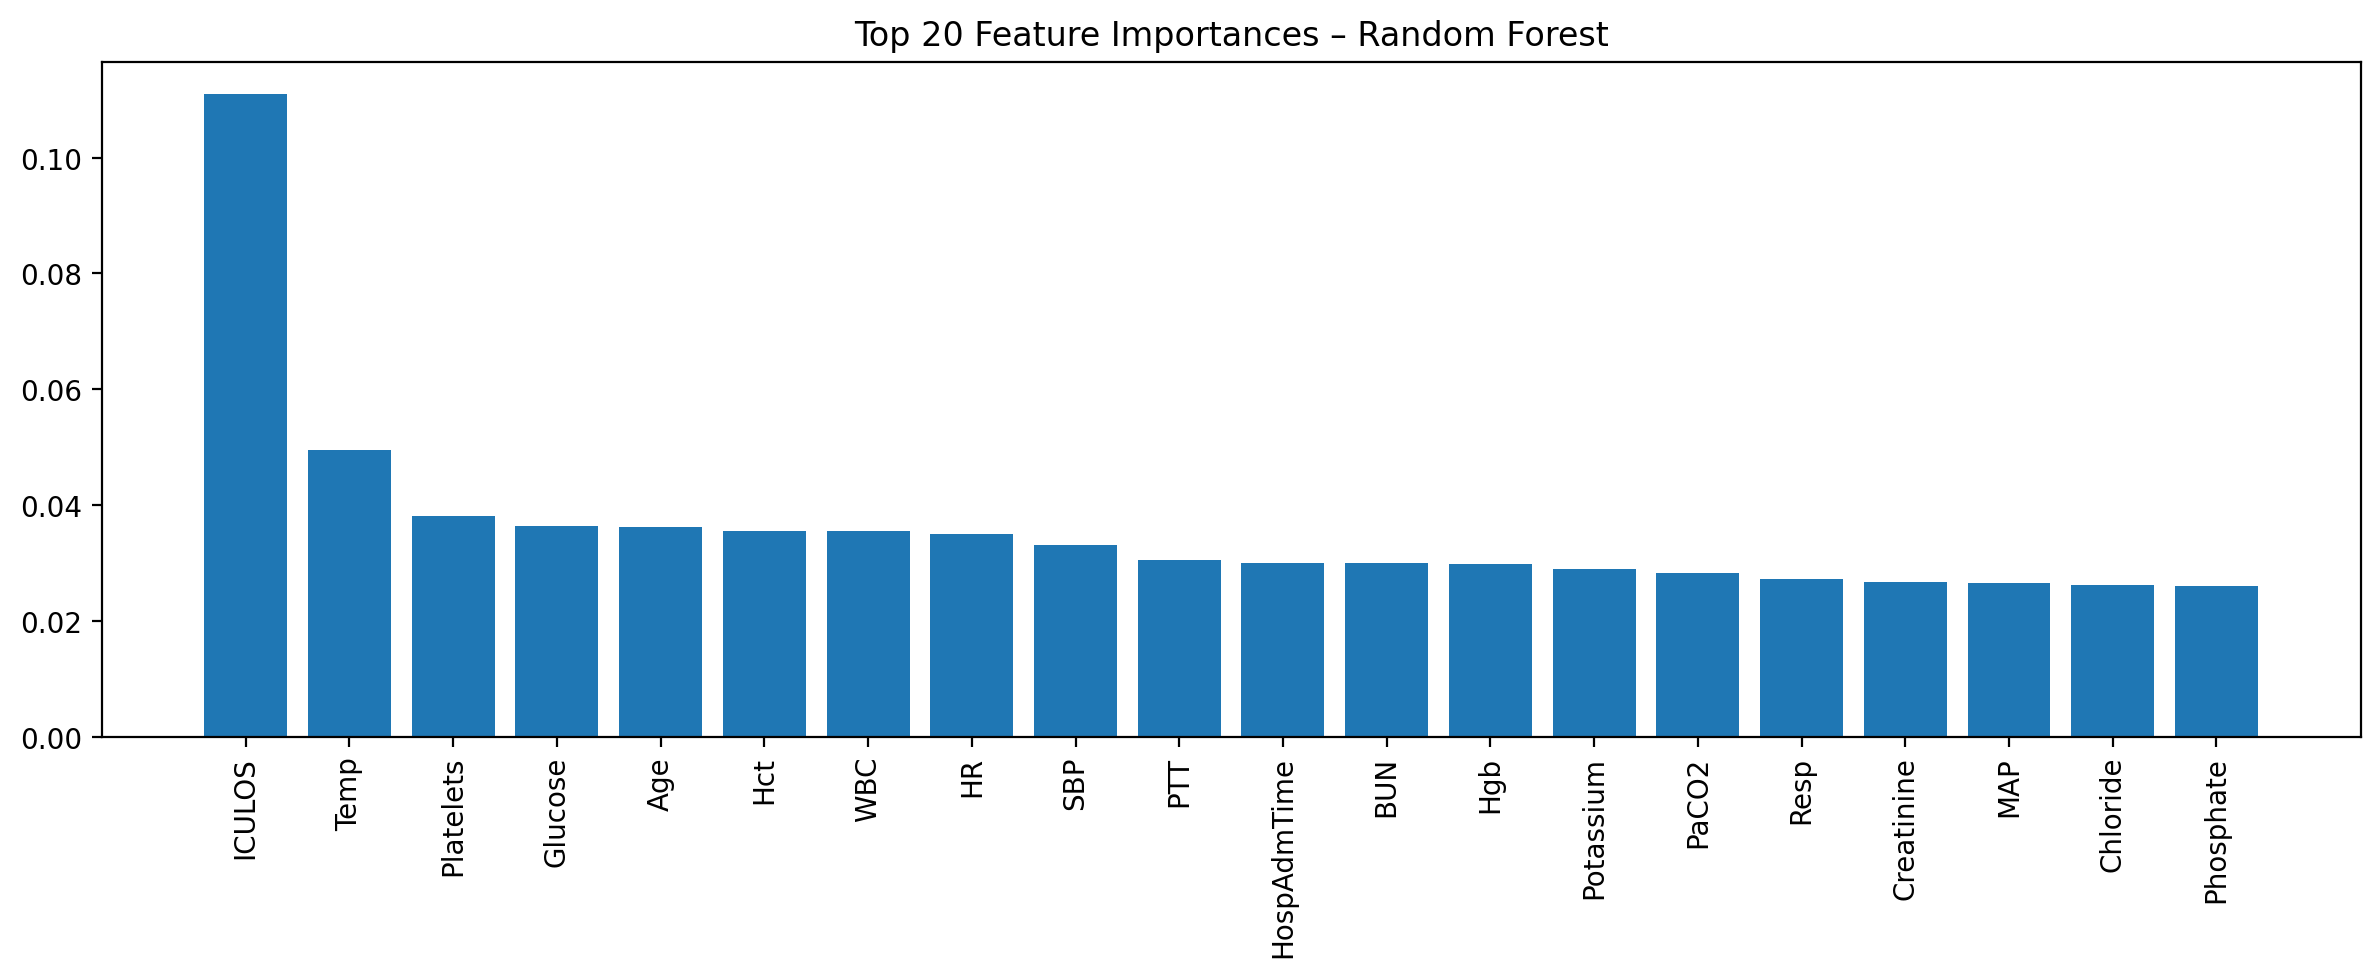

Top 4 most significant features:
  1. ICULOS
  2. Temp
  3. Platelets
  4. Glucose


In [11]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = list(train_df.columns[:-2])

plt.figure(figsize=(12, 5))
plt.title("Top 20 Feature Importances – Random Forest")
plt.bar(range(20), importances[indices[:20]])
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.tight_layout()
plt.show()

print("Top 4 most significant features:")
for k in range(4):
    print(f"  {k+1}. {feature_names[indices[k]]}")

## Hyperparameter Tuning
Use `GridSearchCV` to find optimal hyperparameters.

In [12]:
from sklearn.ensemble import RandomForestClassifier

model_tune = RandomForestClassifier(random_state=42, n_jobs=-1)

hyperparameters = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
}

In [13]:
CLF_PATH        = "./../Data/rf_tuning_clf.joblib"
BEST_MODEL_PATH = "./../Data/rf_tuning_best_model.joblib"

try:
    if not all(os.path.exists(p) for p in [CLF_PATH, BEST_MODEL_PATH]):
        raise FileNotFoundError("One or more joblib files missing")
    clf        = joblib.load(CLF_PATH)
    best_model = joblib.load(BEST_MODEL_PATH)
    print("Loaded clf and best model from joblib files")
except Exception as e:
    print(e)
    print("Error opening files, creating new...")
    clf        = GridSearchCV(model_tune, hyperparameters, cv=5, verbose=2, n_jobs=-1)
    best_model = clf.fit(Xtr, ytr)
    joblib.dump(clf,        CLF_PATH)
    joblib.dump(best_model, BEST_MODEL_PATH)
    print("Saved clf and best model to joblib files")

One or more joblib files missing
Error opening files, creating new...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Saved clf and best model to joblib files


In [14]:
print(type(clf))

<class 'sklearn.model_selection._search.GridSearchCV'>


In [15]:
best_model.best_params_

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

## Test Data Prediction and Performance

In [16]:
# Predict on test set
yhat_ts      = best_model.predict(Xts)
yhat_probas  = best_model.predict_proba(Xts)[:, 1]

acc_ts = np.mean(yhat_ts == yts)
print('Accuracy on the test data is {0:f}'.format(acc_ts))

Accuracy on the test data is 0.976992


Plot ROC and PR curves.

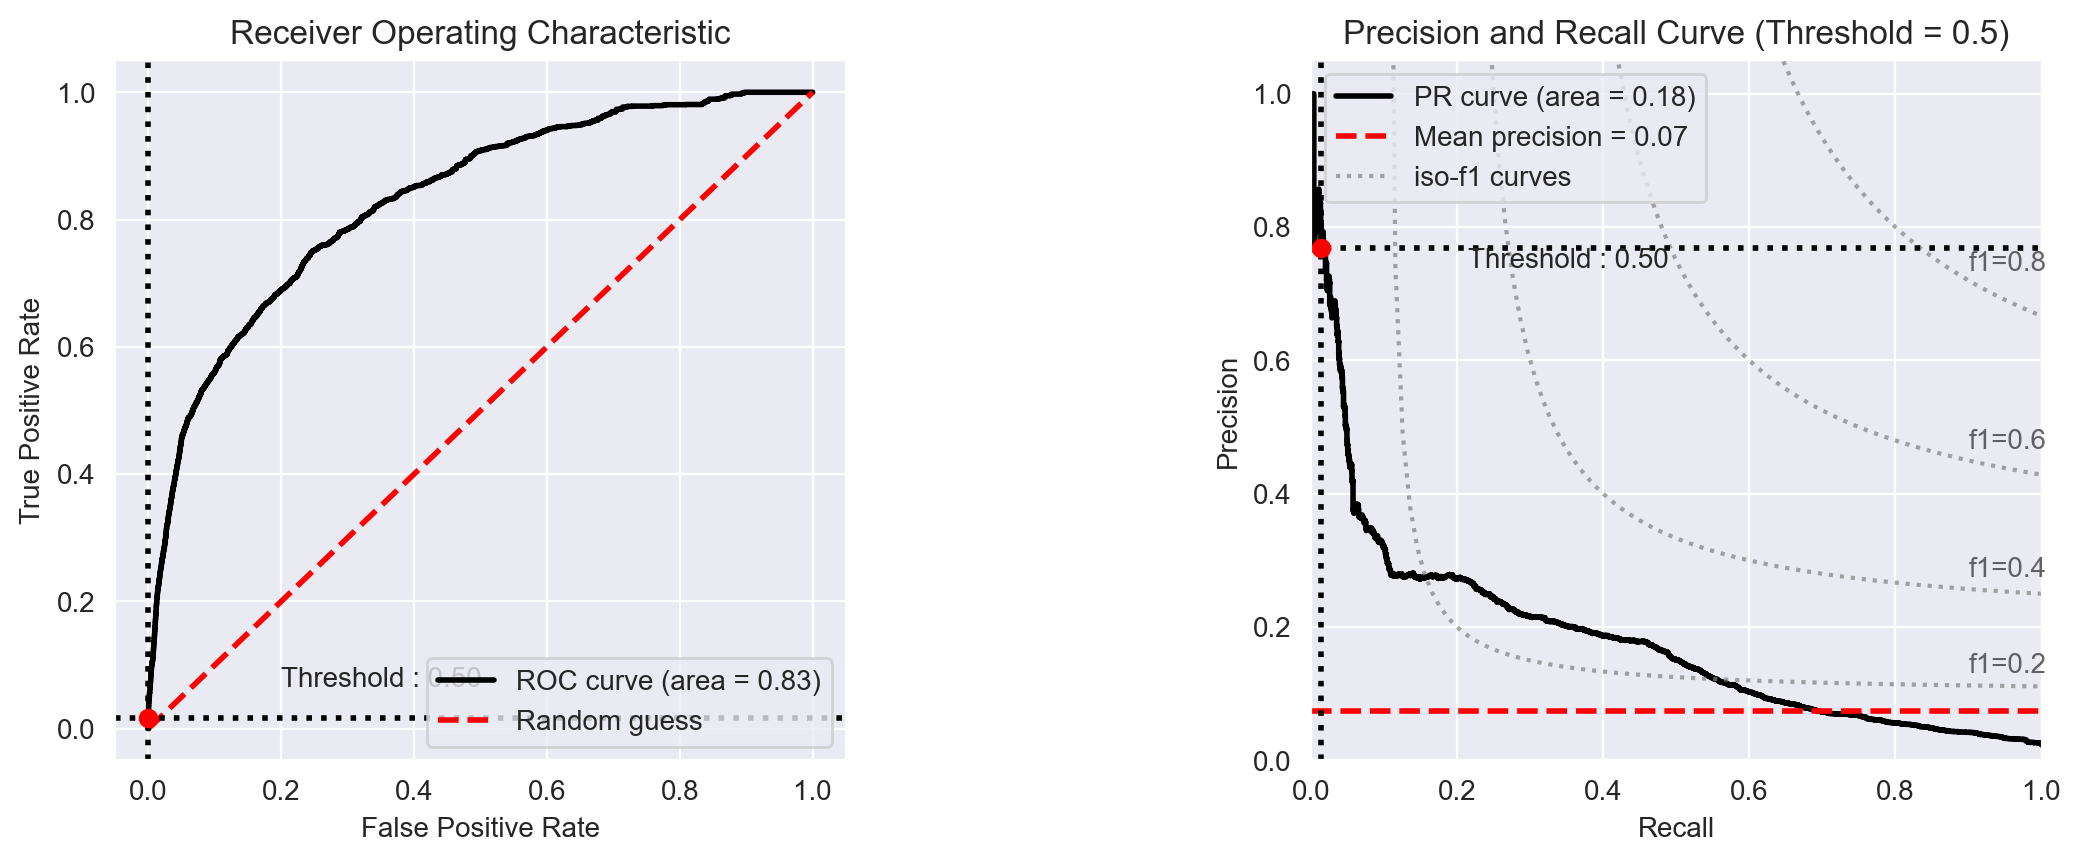

In [17]:
from plot_metric.functions import BinaryClassification
bc = BinaryClassification(yts, yhat_probas, labels=["nonSepsis", "Sepsis"])

plt.figure(figsize=(15, 10))
plt.subplot2grid(shape=(2, 6), loc=(0, 0), colspan=2)
bc.plot_roc_curve()
plt.subplot2grid((2, 6), (0, 3), colspan=2)
bc.plot_precision_recall_curve()
plt.show()

Classification report.

In [18]:
precision, recall, _ = precision_recall_curve(yts, yhat_probas)
fpr, tpr, _          = roc_curve(yts, yhat_probas)

print('f1 score  {0:.4f}:'.format(F(1, np.mean(precision), np.mean(recall))))
print('f2 score  {0:.4f}:'.format(F(2, np.mean(precision), np.mean(recall))))
print('precision {0:.4f}:'.format(precision_score(yts, yhat_ts)))
print('recall    {0:.4f}:'.format(recall_score(yts, yhat_ts)))
print('AUPRC     {0:.4f}:'.format(auc(recall, precision)))
print('AUROC     {0:.4f}:'.format(auc(fpr, tpr)))
print('Acc       {0:.4f}:'.format(accuracy_score(yts, yhat_ts)))

bc.print_report()

f1 score  0.1350:
f2 score  0.2680:
precision 0.7692:
recall    0.0145:
AUPRC     0.1801:
AUROC     0.8310:
Acc       0.9770:
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

   nonSepsis       0.98      1.00      0.99    115852
      Sepsis       0.77      0.01      0.03      2757

    accuracy                           0.98    118609
   macro avg       0.87      0.51      0.51    118609
weighted avg       0.97      0.98      0.97    118609

